In [1]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Add project root to path so we can import 'sim'
sys.path.append(os.path.abspath('..'))

from sim.sim_env import StribeckSystem

# Setup Device
device = 'cpu' # Keep it simple for 1-DoF
print(f"System Ready. running on: {device}")

System Ready. running on: cpu


In [6]:
# --- IMPROVED DATA GENERATION ---

# 1. Initialize
dt = 0.001
sim = StribeckSystem(dt=dt, device=device)
sim.reset()

# 2. Hybrid Excitation Strategy
# Phase A: Fast Chirp (0.5Hz to 2.0Hz) - Captures Viscous/Coulomb
steps_a = 3000
time_a = torch.linspace(0, 3, steps_a)
freq_a = torch.linspace(0.5, 2.0, steps_a)
u_fast = 2.0 * torch.sin(2 * np.pi * freq_a * time_a)

# Phase B: "The Creeper" (Low Frequency, High Amplitude) - Captures Stiction Breakaway
# We oscillate slowly across the 1.0 Nm threshold
steps_b = 2000
time_b = torch.linspace(0, 5, steps_b)
u_slow = 1.5 * torch.sin(2 * np.pi * 0.2 * time_b) # 0.2 Hz slow wave

# Combine Trajectories
u_traj = torch.cat([u_fast, u_slow])

# 3. Run Simulation
data_v = []
data_u = []
data_v_dot = []

state = sim.state
for u in u_traj:
    v_prev = state[1].clone()
    state = sim.step(u)
    v_next = state[1]
    v_dot = (v_next - v_prev) / dt
    
    data_v.append(v_prev)
    data_u.append(u)
    data_v_dot.append(v_dot)

# Convert & Shuffle
# (Shuffling is crucial so the batch isn't just "all fast" then "all slow")
X_train = torch.stack(data_v).unsqueeze(1)
Y_physics = torch.stack(data_u).unsqueeze(1)
Y_accel = torch.stack(data_v_dot).unsqueeze(1)

# Shuffle Indices
indices = torch.randperm(len(X_train))
X_train = X_train[indices]
Y_physics = Y_physics[indices]
Y_accel = Y_accel[indices]

print(f"Refined Data Collected: {len(X_train)} samples")

Refined Data Collected: 5000 samples


In [7]:
class FrictionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Simple MLP: 1 -> 64 -> 64 -> 1
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(), # Tanh is good for smooth physics functions
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1) # Output: Estimated Friction Torque
        )
    
    def forward(self, velocity):
        return self.net(velocity)

model = FrictionNetwork().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
print("Model Initialized.")

Model Initialized.


>>> Starting Attention-Based PINN Training...
Epoch 0: Loss = 0.623516
Epoch 200: Loss = 0.083006
Epoch 400: Loss = 0.059134
Epoch 600: Loss = 0.055005
Epoch 800: Loss = 0.054485
Epoch 1000: Loss = 0.054206
Epoch 1200: Loss = 0.057535
Epoch 1400: Loss = 0.054032
Epoch 1600: Loss = 0.054004
Epoch 1800: Loss = 0.055493
Training Complete.


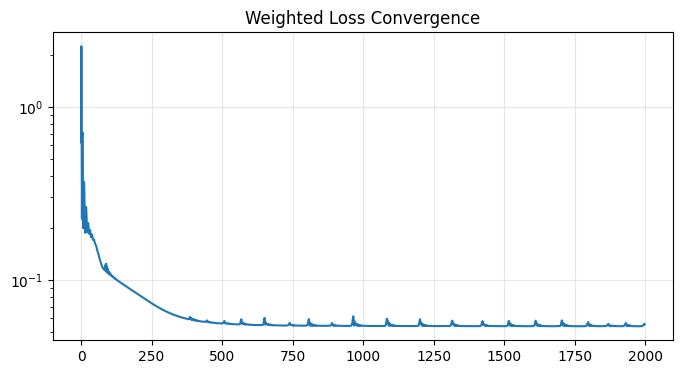

In [8]:
# --- WEIGHTED PHYSICS LOSS ---

epochs = 2000 # Increased epochs for sharper convergence
loss_history = []
J_est = sim.J.item()

print(">>> Starting Attention-Based PINN Training...")

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Forward Pass
    f_pred = model(X_train)
    
    # 2. Compute Raw Residual (Physics Violation)
    # Residual = Torque - (J*accel + Friction_pred)
    raw_residual = Y_physics - (J_est * Y_accel + f_pred)
    
    # 3. Compute Attention Weights
    # Formula: w = 1 + Alpha * exp(-|v| / Width)
    # We boost importance by 20x for velocities under 0.1 rad/s
    weights = 1.0 + 20.0 * torch.exp(-torch.abs(X_train) / 0.1)
    
    # 4. Weighted Loss
    loss = torch.mean(weights * (raw_residual**2))
    
    # 5. Backprop
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

print("Training Complete.")
plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.yscale('log') # Log scale helps see fine convergence
plt.title("Weighted Loss Convergence")
plt.grid(True, alpha=0.3)
plt.show()

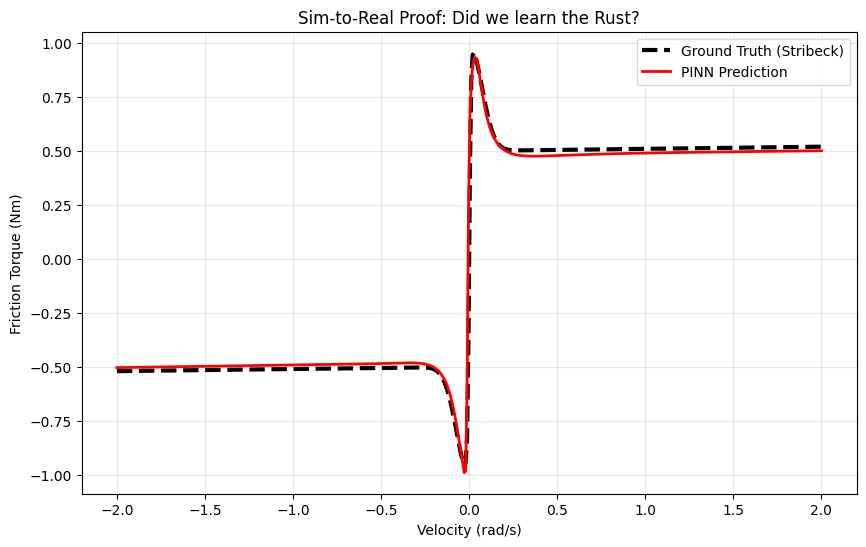

In [9]:
# 1. Generate a clean velocity vector for plotting
v_test = torch.linspace(-2.0, 2.0, 500).unsqueeze(1).to(device)

# 2. Ask Model to predict friction
with torch.no_grad():
    f_learned = model(v_test)

# 3. Ask Simulator for GROUND TRUTH (Cheating, just for validation)
# We access the protected _compute_friction method to see what the 'Real' rust is
# We pass dummy torque=0 because we only care about kinetic friction curve here
f_true = sim._compute_friction(v_test.squeeze(), torque=torch.zeros_like(v_test.squeeze()))

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(v_test.numpy(), f_true.numpy(), 'k--', linewidth=3, label='Ground Truth (Stribeck)')
plt.plot(v_test.numpy(), f_learned.numpy(), 'r', linewidth=2, label='PINN Prediction')

plt.xlabel("Velocity (rad/s)")
plt.ylabel("Friction Torque (Nm)")
plt.title("Sim-to-Real Proof: Did we learn the Rust?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../docs/figures/milestone_week4_result.png')
plt.show()